#1. Import Dataset

In [1]:
import tensorflow as tf


In [2]:
from google.colab import drive
import numpy as np
import pandas as pd


drive.mount('/content/drive/', force_remount=True)

dir = '/content/drive/My Drive/TA/'
import sys
sys.path.insert(0, dir)


import scipy.optimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time
import warnings
from CombinedDecays import CombinedDecays
import datetime


Mounted at /content/drive/


In [ ]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
  try:
    for gpu in gpus:
      print(f"Found GPU: {gpu.name}")
  except RuntimeError as e:
    print(e)
else:
  print("No GPU devices found.")

Found GPU: /physical_device:GPU:0


In [3]:
df = pd.read_csv("/content/drive/My Drive/TA/Dataset/Localized/CO_Land_Grid_Bangkok.csv")
wind = pd.read_csv("/content/drive/My Drive/TA/Dataset/Localized/Wind_CO_MeanDaily_Bangkok_ADM1.csv")


#2. Class Definition

In [ ]:
import tensorflow as tf
import numpy as np
import scipy.optimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time
import warnings

DTYPE='float32'

#Untuk Membangun Fourier Feature dengan Banyak Initial Sigma
class MultiSigmaFourierFeatures(tf.keras.layers.Layer):
    def __init__(self, sigmas, mapping_size, trainable_B=False, **kwargs):
        super().__init__(**kwargs)
        self.sigmas = sigmas
        self.mapping_size = mapping_size
        self.trainable_B = trainable_B
        self.fourier_layers = [
            FourierFeatureMapping(
                mapping_size=self.mapping_size,
                sigma=sigma,
                trainable_B=self.trainable_B
            ) for sigma in self.sigmas
        ]

    def call(self, inputs):
        outputs = [layer(inputs) for layer in self.fourier_layers]
        return tf.concat(outputs, axis=-1)


#Untuk Membangun Fourier Feature pad Satu Initial Sigma
class FourierFeatureMapping(tf.keras.layers.Layer):
    def __init__(self, mapping_size=256, sigma=1.0, trainable_B=False, **kwargs):
        super(FourierFeatureMapping, self).__init__(**kwargs)
        self.mapping_size = mapping_size
        self.sigma = sigma
        self.trainable_B = trainable_B

    def build(self, input_shape):
        input_dim = input_shape[-1]
        # Pakai RandomNormal initializer with stddev = sigma
        self.B = self.add_weight(
            name="B_matrix",
            shape=(input_dim, self.mapping_size),
            initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=self.sigma),
            trainable=self.trainable_B
        )

    def call(self, inputs):
        proj = tf.matmul(inputs, self.B)
        return tf.concat([tf.sin(proj), tf.cos(proj)], axis=-1)

    def get_config(self):
        config = super().get_config()
        config.update({
            "mapping_size": self.mapping_size,
            "sigma": self.sigma,
            "trainable_B": self.trainable_B
        })
        return config

# Define model architecture for 2D spatial domain with time
class PINN_NeuralNet(tf.keras.Model):
    def __init__(self, lb, ub,
                 output_dim=1,
                 num_hidden_layers=8,
                 num_neurons_per_layer=20,
                 activation='swish',
                 mapping_size=256,
                 sigma=1.0,
                 sigmas=[1.0, 3.0],
                 kernel_initializer='glorot_normal',
                 trainable_B=True,
                 **kwargs):
        super().__init__(**kwargs)
        self.lb = lb
        self.ub = ub
        self.num_hidden_layers = num_hidden_layers
        self.output_dim = output_dim
        self.mapping_size = mapping_size
        self.trainable_B = trainable_B
        self.sigmas = sigmas
        self.scale = tf.keras.layers.Lambda(lambda x: 2.0*(x - lb)/(ub - lb) - 1.0)
        self.fourier_features = MultiSigmaFourierFeatures(sigmas=self.sigmas, mapping_size=self.mapping_size, trainable_B=True)
        self.hidden = [tf.keras.layers.Dense(num_neurons_per_layer,
                                             activation=tf.keras.activations.get(activation),
                                             kernel_initializer=kernel_initializer)
                       for _ in range(self.num_hidden_layers)]
        self.out = tf.keras.layers.Dense(output_dim)


    def call(self, X):
        """Forward-pass through neural network."""
        X = tf.convert_to_tensor(X, dtype=tf.float32)  #X = [t, x, y] harus tensor
        X = tf.reshape(X, (-1, 3))  # Memastikan Dimensi input (batch_size, features) untuk [t, x, y]
        Z = self.scale(X)
        Z = self.fourier_features(Z) #melakukan fourier freatures dengan multisigma
        for i in range(self.num_hidden_layers): #hidden layers
            Z = self.hidden[i](Z)
        return self.out(Z)

class PINN_PDESolver():
    def __init__(self, model, X_r, fun_r, get_r,lambd=1):
        self.model = model

        # Store collocation points
        # X_r = tf.convert_to_tensor(X_r, dtype=tf.float32)  # Ensure X_r is a Tensor
        self.t = X_r[:,0:1]
        self.x = X_r[:,1:2]
        self.y = X_r[:,2:3]
        self.lambd = lambd
        # Initialize history of losses and global iteration counter
        self.hist = []
        self.lambd_list = []  # Initialize lambda list here
        self.iter = 0
        self.fun_r = fun_r
        self.get_r_fn = get_r

    def get_r(self, t, x, y, u_data, Wu=None, Wv=None): # Added default None for Wu, Wv
        return self.get_r_fn(t=t, x=x, y=y, model=self.model, lambd = self.lambd, fun_r=self.fun_r, u_data=u_data, Wu=Wu, Wv=Wv)


    def loss_fn(self, X, u, Wu, Wv):
        # X = tf.convert_to_tensor(X, dtype=tf.float32)
        # X = tf.reshape(X, (-1, 3))  # Ensure input is 3D [t, x, y]
        # u = tf.convert_to_tensor(u, dtype=tf.float32)

        # Compute phi_r
        t = X[:, 0:1]
        x = X[:, 1:2]
        y = X[:, 2:3]
        r = self.get_r(t, x, y, u, Wu, Wv)
        phi_r = r

        # Initialize loss
        loss = phi_r

        return loss, phi_r
    @tf.function
    def get_grad(self, X, u, Wu, Wv):
        X = tf.cast(X, tf.float32)
        u = tf.cast(u, tf.float32)
        Wu = tf.cast(Wu, tf.float32)
        Wv = tf.cast(Wv, tf.float32)


        with tf.GradientTape() as tape:
            loss, phi_r = self.loss_fn(X, u, Wu, Wv)
        grad_theta = tape.gradient(loss, self.model.trainable_variables)

        return loss, grad_theta

    def solve_with_TFoptimizer(self, optimizer, X, u, W_u, W_v, inverse=True, N=None, min_loss=None, timeout=None, batch_size=None):
        """
        Modified training loop that keeps the loss_callback function and reports loss per iteration.
        """
        X = tf.convert_to_tensor(X, dtype=tf.float32)
        u = tf.convert_to_tensor(u, dtype=tf.float32)
        W_u = tf.convert_to_tensor(W_u, dtype=tf.float32)
        W_v = tf.convert_to_tensor(W_v, dtype=tf.float32)


        data = tf.data.Dataset.from_tensor_slices((X, u, W_u, W_v))

        if batch_size is not None:
            data = data.shuffle(buffer_size=len(X)).batch(batch_size).map(
                lambda x, u_batch, wu, wv: (tf.cast(x, tf.float32), tf.cast(u_batch, tf.float32), tf.cast(wu, tf.float32), tf.cast(wv, tf.float32))
            ).prefetch(tf.data.AUTOTUNE)
        else:
            data = data.batch(len(X)).map(
                lambda x, u_batch, wu, wv: (tf.cast(x, tf.float32), tf.cast(u_batch, tf.float32), tf.cast(wu, tf.float32), tf.cast(wv, tf.float32))
            ).prefetch(tf.data.AUTOTUNE)


        # The loss_callback now accepts the results of a step as arguments.
        def loss_callback(loss, phi_r, epoch_num):
            self.current_loss = loss.numpy()
            self.phi_r = phi_r.numpy()

            # Print every 50 iterations to avoid excessive output
            if self.iter % 50 == 0:
                print(f"Epoch {epoch_num}, Iteration {self.iter}, Loss: {self.current_loss:.6e}, Phi_r: {self.phi_r:.6e}")

            self.hist.append(self.current_loss)
            self.iter += 1

        start_time = time.time()
        epochs = N if N is not None else 1000 # Set a default number of epochs if N isn't specified

        # Explicit loops for epochs and iterations (batches)
        for epoch in range(epochs):
            if timeout is not None and (time.time() - start_time > timeout):
                print("Timeout reached. Stopping training.")
                break

            total_epoch_loss = 0
            num_batches = 0
            for batch_X, batch_u, batch_Wu, batch_Wv in data:
                # Execute one training step (one batch)
                loss, grads = self.get_grad(batch_X, batch_u, batch_Wu, batch_Wv)
                optimizer.apply_gradients(zip(grads, self.model.trainable_variables))

                # Accumulate loss for the epoch
                total_epoch_loss += loss.numpy()
                num_batches += 1

                # Recalculate phi_r for reporting (optional, can be removed for speed)
                # phi_r = self.loss_fn(batch_X, batch_u, batch_Wu, batch_Wv)[1]
                # loss_callback(loss, phi_r, epoch + 1) # Callback per batch (noisy)

            # Calculate average epoch loss and call callback once per epoch
            avg_epoch_loss = total_epoch_loss / num_batches if num_batches > 0 else 0
            # We don't have phi_r readily available as it's calculated per batch,
            # so we'll just report the average epoch loss.
            self.current_loss = avg_epoch_loss
            self.hist.append(self.current_loss)
            self.iter += 1 # Increment iteration counter once per epoch

            # Print every epoch
            print(f"--- End of Epoch {epoch+1}, Iteration {self.iter}, Average Epoch Loss: {self.current_loss:.6e} ---")


            if min_loss is not None and self.current_loss < min_loss:
                print(f"Minimum loss of {min_loss} reached. Stopping training.")
                break


    def callback(self, xr=None):
        if self.iter % 50 == 0:
            print('It {:05d}: l_u = {:10.8e} loss = {:10.8e}'.format(self.iter,self.phi_0_b,self.current_loss))
        self.hist.append(self.current_loss)
        self.iter+=1

    def predict_solution(self, test_data,t_unique,x_unique,y_unique):
        # Predict using the scaled input
        upred = self.model(tf.cast(test_data, DTYPE))  # shape: [N, 1]

        # Reshape into [Nt+1, Nx+1, Ny+1]
        Nt, Nx, Ny = len(t_unique) - 1, len(x_unique) - 1, len(y_unique) - 1
        U = upred.numpy().reshape(Nt+1, Nx+1, Ny+1)

        # Create meshgrid for visualization
        T, X, Y = np.meshgrid(t_unique, x_unique, y_unique, indexing='ij')
        self.T_pred, self.X_pred, self.Y_pred = T, X, Y

        return U

    def plot_solution_at_time(self, U=None, time_idx=0, **kwargs):
        # If upred has not been predicted
        if U is None:
            U = self.predict_solution()

        # Plot solution at specific time
        fig = plt.figure(figsize=(9,6))
        ax = fig.add_subplot(111, projection='3d')
        ax.plot_surface(self.X_pred[time_idx], self.Y_pred[time_idx], U[time_idx], cmap='viridis', **kwargs)
        ax.set_xlabel('$x$')
        ax.set_ylabel('$y$')
        ax.set_zlabel('$u_\\theta(t,x,y)$')
        ax.set_title(f'Solution at t = {self.T_pred[time_idx,0,0]:.2f}')
        return ax

    def plot_loss_history(self, ax=None):
        if not ax:
            fig = plt.figure(figsize=(7,5))
            ax = fig.add_subplot(111)
        ax.semilogy(range(len(self.hist)), self.hist,'k-')
        ax.set_xlabel('$n_{epoch}$')
        ax.set_ylabel('$\\phi^{n_{epoch}}$')
        return ax



#self disini adalah modelnya
def predict_solution(self, test_data,t_unique,x_unique,y_unique):
        # Predict using the scaled input
    upred = self(tf.cast(test_data, DTYPE))  # shape: [N, 1]
    return upred

def calculate_mae(u_pred, u_true):
    """Calculate Mean Absolute Error"""
    return np.mean(np.abs(u_true - u_pred))

def calculate_mape(u_pred, u_true, epsilon=1e-10):
    """Calculate Mean Absolute Percentage Error"""
    return 100 * np.mean(np.abs((u_true - u_pred) / (np.abs(u_true) + epsilon)))

def evaluate_solution(u_pred, u_true):
    """Evaluate solution using MAE and MAPE"""
    mae = calculate_mae(u_pred, u_true)
    mape = calculate_mape(u_pred, u_true)
    # r2 =   calculate_rel_l2(u_pred, u_true)

    return mae, mape

def calculate_rel_l2(u_pred, u_true, epsilon=1e-10):
    """Relative L2 norm error"""
    return np.linalg.norm(u_pred - u_true) / (np.linalg.norm(u_true) + epsilon)


def evaluate_param(lambda_pred, lambda_true):
    """Evaluate parameter using absolute error and percentage error"""
    abs_error = np.abs(lambda_true - lambda_pred)
    perc_error = 100 * abs_error / np.abs(lambda_true)
    return abs_error, perc_error

#Arsitektur dari H-PINN (inherit dari arsitektur PINN)
class Hybrid_IdentificationNet(PINN_NeuralNet):
    def __init__(self, initial_lambda, *args, **kwargs):
        super().__init__(*args,**kwargs)
        self.initial_lambda = initial_lambda

        if isinstance(initial_lambda, (list, np.ndarray)):
            self.initial_lambda = np.array(initial_lambda, dtype=DTYPE)
        else:
            self.initial_lambda = initial_lambda

        # Initialize variable for lambda
        self.lambd = tf.Variable(initial_value=self.initial_lambda, trainable=True, dtype=DTYPE, constraint=lambda x: tf.clip_by_value(x, 1e-5, 10.0))
        self.lambd_list = []

    def build(self, input_shape):
           super().build(input_shape)
           self.built = True


    def add_param(self):
        try:
          len(self.initial_lambda)
          self.initial_lambda = np.array(self.initial_lambda, dtype=DTYPE)
        except TypeError as e:
          pass

    @property
    def trainable_variables(self):
        return super().trainable_variables + [self.lambd]

#Cara optimasi dari HPINN
class Hybrid_IdentificationSolver(PINN_PDESolver):
    def solve_with_TFoptimizer(self, optim_fwd, optim_param, get_r_param,
                           X, u, W_u, W_v,
                           N_fwd=None, min_loss_fwd=None, timeout_fwd=None,
                               N_param=None, min_loss_param=None, timeout_param=None,
                               modified=False, **kwargs):

        self.changed = False
        self.lambd_list = []

        # ================================
        # Forward optimization (NO batching, full dataset)
        # ================================
        print("\n\nForward optimization (full dataset)")
        self.iter = 0
        self.hist = []
        import time
        start_time = time.time()

        @tf.function
        def train_step_fwd():
            with tf.GradientTape() as tape:
                loss, _ = self.loss_fn(X, u, W_u, W_v) # Pass W_u, W_v here
            grads = tape.gradient(loss, self.model.trainable_variables)
            optim_fwd.apply_gradients(zip(grads, self.model.trainable_variables))
            return loss

        if N_fwd is not None:
            N_fwd = int(N_fwd)
            for _ in range(N_fwd):
                loss = train_step_fwd()
                self.current_loss = loss.numpy()
                self.hist.append(self.current_loss)
                self.iter += 1
            print(f"{N_fwd} forward iterations reached.")
        elif min_loss_fwd is not None:
            while True:
                loss = train_step_fwd()
                self.current_loss = loss.numpy()
                self.hist.append(self.current_loss)
                self.iter += 1
                if self.current_loss < min_loss_fwd:
                    print(f"Forward loss target reached: {self.current_loss:.3e}")
                    break
        elif timeout_fwd is not None:
            stop_after = time.time() + timeout_fwd
            while True:
                loss = train_step_fwd()
                self.current_loss = loss.numpy()
                self.hist.append(self.current_loss)
                self.iter += 1
                print(f"Iteration {self.iter}, Loss: {self.current_loss}")
                if time.time() > stop_after:
                    print(f"Forward timeout reached ({time.time()-start_time:.1f}s)")
                    break

        # ================================
        # Add PDE parameters
        # ================================
        self.model.add_param()
        self.changed = True
        print('\n\nFinding PDE parameters...')

        # ================================
        # Lambda penalty
        # ================================
        def lambda_penalty_hinge(lam=self.model.lambd, lam_min=1e-3, alpha=1e-2):
            return alpha * tf.square(tf.nn.relu(lam_min - lam))

        # ================================
        # Inverse optimization
        # ================================
        if modified:
            @tf.function
            def train_step_param():
                loss, grad_theta = get_r_param(self.t, self.x, self.y, W_u, W_v, self.model)
                optim_param.apply_gradients(zip([grad_theta], [self.model.lambd]))
                return loss
        else:
            @tf.function
            def train_step_param():
                with tf.GradientTape(persistent=True) as tape_lambd: # Make tape persistent
                    tape_lambd.watch(self.model.lambd)
                    loss = self.get_r(self.t, self.x, self.y, u, W_u, W_v) # Pass arguments here
                    loss += lambda_penalty_hinge(self.model.lambd, lam_min=1e-3, alpha=1e-2)
                grad_lambd = tape_lambd.gradient(loss, self.model.lambd)
                del tape_lambd # Delete tape when done
                optim_param.apply_gradients(zip([grad_lambd], [self.model.lambd]))
                return loss

        def callback():
            lambd = self.model.lambd.numpy()
            self.model.lambd_list.append(lambd)
            if self.iter % 10 == 0:
                print(f"It {self.iter:05d}: loss = {self.current_loss:.3e} lambda = {lambd}")
            self.hist.append(self.current_loss)
            self.iter += 1

        def loss_callback():
            loss = train_step_param()
            self.current_loss = loss.numpy()
            callback()

        start_time = time.time()
        if N_param is not None:
            N_param = int(N_param)
            for _ in range(N_param):
                loss_callback()
            print(f"{N_param} inverse iterations reached.")
        elif min_loss_param is not None:
            while True:
                loss_callback()
                if self.current_loss < min_loss_param:
                    print(f"Inverse loss target reached: {self.current_loss:.3e}")
                    break
        elif timeout_param is not None:
            stop_after = time.time() + timeout_param
            while True:
                loss_callback()
                if time.time() > stop_after:
                    print(f"Inverse timeout reached ({time.time()-start_time:.1f}s)")
                    break

    # ======================================================
    # Loss fn same as yours, but takes full dataset
    # ======================================================
    def loss_fn(self, X, u, Wu, Wv): # Added Wu, Wv here
        if self.changed:
            t = X[:, 0:1]
            x = X[:, 1:2]
            y = X[:, 2:3]
            r = self.get_r(t, x, y, u, Wu, Wv) # Pass arguments here
            loss = r
            return loss, r
        else:
            u_pred = self.model(X)
            loss = tf.reduce_mean(tf.square(u - u_pred))
            return loss, 0.0

    def callback(self, xr=None):
        if self.iter % 50 == 0:
            print(f"It {self.iter:05d}: l_u = {self.phi_0_b:.3e} loss = {self.current_loss:.3e}")
        self.hist.append(self.current_loss)
        self.iter += 1

# 3. Data PreProcessing and Training-Testing Split

In [ ]:
df.columns

NameError: name 'df' is not defined

In [4]:
# df = CO_df.drop(columns=['Unnamed: 0'])
# df = df.drop(columns=['Unnamed: 0'])
# wind = wind.drop(columns=['Unnamed: 0'])

wind.dropna(inplace=True)
df.dropna(inplace = True)

In [5]:
wind

,date,longitude,latitude,u_component_of_wind_10m,v_component_of_wind_10m,wind_speed_10m,wind_direction_10m
1,2023-05-01,100.344430,13.659806,-0.714126,1.163645,1.365301,301.537324
2,2023-05-01,100.343531,13.672576,-0.714126,1.163645,1.365301,301.537324
3,2023-05-01,100.342411,13.683985,-0.735061,1.166819,1.379144,302.203011
4,2023-05-01,100.343295,13.697225,-0.714126,1.163645,1.365301,301.537324
5,2023-05-01,100.342132,13.708964,-0.735061,1.166819,1.379144,302.203011
...,...,...,...,...,...,...,...
556252,2025-04-29,100.917067,13.829651,-0.815294,0.331706,0.880189,337.860854
556255,2025-04-29,100.914732,13.931925,-0.804878,0.177327,0.824180,347.575309
556256,2025-04-29,100.915276,13.942720,-0.804878,0.177327,0.824180,347.575309
556258,2025-04-29,100.932461,13.807774,-0.815294,0.331706,0.880189,337.860854


In [6]:
df

,date,mean,longitude,latitude
1,2023-05-01,0.047541,100.344430,13.659806
2,2023-05-01,0.047541,100.343531,13.672576
3,2023-05-01,0.046947,100.342411,13.683985
4,2023-05-01,0.047541,100.343295,13.697225
5,2023-05-01,0.046947,100.342132,13.708964
...,...,...,...,...
555724,2025-04-29,0.036072,100.512448,13.770892
555725,2025-04-29,0.036072,100.512448,13.783242
555726,2025-04-29,0.036072,100.512543,13.795519
555727,2025-04-29,0.036072,100.515911,13.806028


In [7]:
df['date'] = pd.to_datetime(df['date'])
start_date = datetime.datetime(2023, 5, 1)
df = df[(df['date'] >= start_date)]
df=df.rename(columns={"longitude":"x_coord","latitude":"y_coord"})
wind=wind.rename(columns={"longitude":"x_coord","latitude":"y_coord"})

df.sort_values(by=['date','x_coord','y_coord'], inplace=True)

In [8]:
df.describe()

,date,mean,x_coord,y_coord
count,360681,360681.000000,360681.000000,360681.000000
mean,2024-05-10 19:29:59.925141504,0.040013,100.624507,13.770165
min,2023-05-01 00:00:00,0.016655,100.339988,13.499866
25%,2023-11-30 00:00:00,0.031567,100.480998,13.709142
50%,2024-04-23 00:00:00,0.039551,100.622523,13.770892
75%,2024-11-21 00:00:00,0.046935,100.764048,13.844992
max,2025-04-29 00:00:00,0.077132,100.932461,13.951460
std,NaN,0.009979,0.162657,0.095403


In [9]:
wind.describe()

,x_coord,y_coord,u_component_of_wind_10m,v_component_of_wind_10m,wind_speed_10m,wind_direction_10m
count,521220.000000,521220.000000,521220.000000,521220.000000,521220.000000,521220.000000
mean,100.627654,13.772670,0.277864,0.752950,2.112851,186.640131
std,0.163076,0.093959,1.383108,1.666853,0.933688,95.189663
min,100.339988,13.500866,-4.674856,-4.757746,0.015524,0.128686
25%,100.480998,13.709142,-0.634826,-0.564127,1.459490,74.091181
50%,100.622523,13.770892,0.159854,1.059122,2.151554,221.339469
75%,100.764048,13.844992,1.248510,1.967801,2.762007,261.968080
max,100.932461,13.951460,5.253960,6.101706,6.105534,359.960850


In [ ]:
df=df.rename(columns={"mean":"CO_mean"})

df = df[df["CO_mean"]>=0]

wind['date'] = pd.to_datetime(wind['date'])

merged_df = pd.merge(df, wind, on=['x_coord', 'y_coord', 'date'], how='inner')

display(merged_df.head())

In [ ]:
merged_df= merged_df.rename(columns = {"u_component_of_wind_10m":'u10',"v_component_of_wind_10m":'v10'})
merged_df = merged_df[["date","CO_mean","u10","v10","x_coord","y_coord"]]

merged_df['u10']  = merged_df.groupby(['x_coord','y_coord'])['u10'].transform('mean')
merged_df['v10']  = merged_df.groupby(['x_coord','y_coord'])['v10'].transform('mean')

In [ ]:
merged_df.describe()

In [ ]:
import geopandas as gpd
from shapely.geometry import Point
from datetime import datetime, timedelta

df['time'] = (df['date'] - df['date'].min()).dt.days

start_date = datetime(2023, 5, 1)

target_day = 8
target_month = 1
target_year = 2025

target_date = datetime(target_year, target_month, target_day)

t = (target_date - start_date).days
print("t =", t)

time_to_visualize = t

df_visualize = df[df['time'] == time_to_visualize].copy()
if df_visualize.empty:
    print(f"No prediction data found for time = {time_to_visualize}.")
else:
    print(f"Filtered prediction data for time = {time_to_visualize}. Shape: {df_visualize.shape}")
    display(df_visualize.head())

    thailand_full = gpd.read_file('https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_THA_1.json')
    thailand = thailand_full[thailand_full['NAME_1'] == 'BangkokMetropolis'].copy()

In [ ]:

    # --- 4. Merge Data ---
    # Create a GeoDataFrame from the filtered prediction data
    geometry = [Point(xy) for xy in zip(df_visualize['x_coord'], df_visualize['y_coord'])]
    gdf = gpd.GeoDataFrame(df_visualize, geometry=geometry)
    print("Jumlah Koordinat Unik:", len(geometry))
    merged_gdf = gpd.sjoin(gdf, thailand, how="inner", predicate="within")

    print("\nMerged GeoDataFrame:")
    display(merged_gdf.head())


    # --- 5. Visualize Predictions ---
    fig, ax = plt.subplots(1, 1, figsize=(20, 15))

    # Plot the base map of Java with edge boundaries
    thailand.plot(ax=ax, color='lightgray', edgecolor='black')

    if not merged_gdf.empty:
        merged_gdf.plot(column='CO_mean', ax=ax, legend=True,
                        cmap='viridis',
                        legend_kwds={'label': "CO",
                                    'orientation': "horizontal"})

    # --- Tambahkan nama kota/kabupaten ---
    # Hitung centroid dari setiap polygon
    thailand.boundary.plot(ax=ax, color='black', linewidth=1)

    thailand['centroid'] = thailand.geometry.centroid

    # Tambahkan teks nama kota/kabupaten pada posisi centroid
    for idx, row in thailand.iterrows():
        plt.annotate(text=row['NAME_1'],
                    xy=(row['centroid'].x, row['centroid'].y),
                    horizontalalignment='center',
                    fontsize=10,
                    color='black',
                    weight='bold')

    # Set plot title and labels
    ax.set_title(f'CO di Bangkok pada Waktu {target_day}-{target_month}-{target_year}', fontsize=20)
    ax.set_xlabel('Bujur', fontsize=20)
    ax.set_ylabel('Lintang', fontsize=20)

    plt.show()


In [ ]:
merged_df = merged_df[["date","CO_mean","u10","v10","x_coord","y_coord"]]

In [ ]:
merged_df.to_csv("/content/drive/My Drive/TA/Dataset/Localized/Bangkok_Preprocessed_Local_CO.csv")

In [ ]:
df = pd.read_csv("/content/drive/My Drive/TA/Dataset/Localized/Bangkok_Preprocessed_Local_CO.csv",index_col=0)

In [ ]:
df['date'] = pd.to_datetime(df['date'])

In [ ]:
#Convert to Numerical Value
df['time'] = (df['date'] - df['date'].min()).dt.days
scale = 1e-2
df.CO_mean = df.CO_mean/scale
df.x_coord = df.x_coord*100
df.y_coord = df.y_coord*100

In [ ]:
def low_pass_filter(series, cutoff=0.1):
    """Applies a low-pass filter to a pandas Series."""
    signal = series.values
    fft_vals = np.fft.fft(signal)
    freqs = np.fft.fftfreq(len(signal), d=1) # d=1 assumes unit time spacing

    # Apply the ideal low-pass filter
    mask = np.abs(freqs) < cutoff
    filtered_fft = fft_vals * mask

    # Return the real part of the inverse FFT
    return np.fft.ifft(filtered_fft).real


full_dates = pd.date_range(start=df['date'].min(),end=df['date'].max(),freq='D')
df2 = (df.set_index('date').groupby(['x_coord', 'y_coord']).apply(lambda g: g.reindex(full_dates)).reset_index(level=[0,1]).rename_axis('date').reset_index())
df2['CO_mean'] = (df2.groupby(['x_coord', 'y_coord'])['CO_mean'].apply(lambda s: s.interpolate(method='linear', limit_direction='both')))
df['CO_filtered'] = df.groupby(['x_coord', 'y_coord'])['CO_mean'].transform(low_pass_filter)
df = df[['date', 'CO_mean','u10','v10','x_coord', 'y_coord','time']].merge(
    df[['date', 'x_coord', 'y_coord', 'CO_filtered']],
    on=['date', 'x_coord', 'y_coord'],
    how='left'
)

print(df.head())

        date   CO_mean       u10       v10       x_coord      y_coord  time  \
0 2023-05-01  4.760029  0.220822  0.673953  10033.998832  1379.552182     0   
1 2023-05-01  4.760029  0.220822  0.673953  10034.020545  1375.858184     0   
2 2023-05-01  4.760029  0.220822  0.673953  10034.033782  1377.082343     0   
3 2023-05-01  4.760029  0.220822  0.673953  10034.041709  1378.330966     0   
4 2023-05-01  4.764919  0.221065  0.682669  10034.113409  1374.650879     0   

   CO_filtered  
0     4.222503  
1     4.222503  
2     4.222503  
3     4.222503  
4     4.221941  


In [ ]:
df.describe()

,date,CO_mean,u10,v10,x_coord,y_coord,time,CO_filtered
count,357580,357580.000000,357580.000000,357580.000000,357580.000000,357580.000000,357580.000000,357580.000000
mean,2024-05-10 17:44:20.564908800,4.000970,0.190755,0.760940,10062.631759,1377.228390,375.739127,4.000970
min,2023-05-01 00:00:00,1.696875,-0.010655,0.609089,10033.998832,1350.086598,0.000000,2.189114
25%,2023-11-30 00:00:00,3.156743,0.155074,0.661949,10048.099837,1370.914189,213.000000,3.164708
50%,2024-04-23 00:00:00,3.953971,0.193014,0.744102,10062.252337,1377.089189,358.000000,4.011513
75%,2024-11-21 00:00:00,4.692287,0.235795,0.835591,10076.404837,1384.499189,570.000000,4.671608
max,2025-04-29 00:00:00,7.713246,0.293870,1.278688,10093.246063,1395.146001,729.000000,6.620007
std,NaN,0.997306,0.067154,0.112144,16.218906,9.302805,211.103674,0.928850


In [ ]:
from scipy.stats import kstest
import pandas as pd


def check_normality(group):
    """
    Calculates KS test for normality on the residuals of a given group.
    """
    residuals = group['CO_mean'] - group['CO_filtered']
    std_residuals = residuals.std()

    # Handle cases where all residuals are the same
    if std_residuals == 0:
        return pd.Series({
            'Test Statistic (KS)': None,
            'P-value (KS)': None,
            'Normality (KS)': "Standard deviation is zero",
            'Data Points': len(residuals)
        })

    # Perform the KS test
    mean_residuals = residuals.mean()
    stat, p = kstest(residuals, 'norm', args=(mean_residuals, std_residuals))

    # Determine normality based on the p-value
    normality = "Gaussian" if p > 0.01 else "Not Gaussian"

    return pd.Series({
        'Test Statistic (KS)': stat,
        'P-value (KS)': p,
        'Normality (KS)': normality,
        'Data Points': len(residuals)
    })

# Group by coordinates only and apply the function
normality_results_df = df.groupby(['x_coord', 'y_coord']).apply(check_normality).reset_index()

# Display the first few rows of the results
print(normality_results_df.head())

        x_coord      y_coord  Test Statistic (KS)  P-value (KS)  \
0  10033.998832  1379.552182             0.063691      0.030286   
1  10034.020545  1375.858184             0.063691      0.030286   
2  10034.033782  1377.082343             0.063691      0.030286   
3  10034.041709  1378.330966             0.063691      0.030286   
4  10034.113409  1374.650879             0.066488      0.020825   

  Normality (KS)  Data Points  
0       Gaussian          511  
1       Gaussian          511  
2       Gaussian          511  
3       Gaussian          511  
4       Gaussian          511  


/tmp/ipython-input-1252786904.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  normality_results_df = df.groupby(['x_coord', 'y_coord']).apply(check_normality).reset_index()


In [ ]:
normality_results_df["Normality (KS)"].value_counts()

,count
Normality (KS),
Gaussian,714


In [ ]:
df.describe()

,date,CO_mean,u10,v10,x_coord,y_coord,time,CO_filtered
count,357580,357580.000000,357580.000000,357580.000000,357580.000000,357580.000000,357580.000000,357580.000000
mean,2024-05-10 17:44:20.564908800,4.000970,0.190755,0.760940,10062.631759,1377.228390,375.739127,4.000970
min,2023-05-01 00:00:00,1.696875,-0.010655,0.609089,10033.998832,1350.086598,0.000000,2.189114
25%,2023-11-30 00:00:00,3.156743,0.155074,0.661949,10048.099837,1370.914189,213.000000,3.164708
50%,2024-04-23 00:00:00,3.953971,0.193014,0.744102,10062.252337,1377.089189,358.000000,4.011513
75%,2024-11-21 00:00:00,4.692287,0.235795,0.835591,10076.404837,1384.499189,570.000000,4.671608
max,2025-04-29 00:00:00,7.713246,0.293870,1.278688,10093.246063,1395.146001,729.000000,6.620007
std,NaN,0.997306,0.067154,0.112144,16.218906,9.302805,211.103674,0.928850


In [ ]:
averaged_df = df.groupby(['x_coord', 'y_coord'])[['u10', 'v10']].mean().reset_index()
df_for_update = df.drop(columns=['u10', 'v10'])
filtered_df = pd.merge(df_for_update, averaged_df, on=['x_coord', 'y_coord'], how='left')
filtered_df

,date,CO_mean,x_coord,y_coord,time,CO_filtered,u10,v10
0,2023-05-01,4.760029,10033.998832,1379.552182,0,4.222503,0.220822,0.673953
1,2023-05-01,4.760029,10034.020545,1375.858184,0,4.222503,0.220822,0.673953
2,2023-05-01,4.760029,10034.033782,1377.082343,0,4.222503,0.220822,0.673953
3,2023-05-01,4.760029,10034.041709,1378.330966,0,4.222503,0.220822,0.673953
4,2023-05-01,4.764919,10034.113409,1374.650879,0,4.221941,0.221065,0.682669
...,...,...,...,...,...,...,...,...
357575,2025-04-29,3.670541,10051.244837,1364.739189,729,4.256327,0.288618,0.976043
357576,2025-04-29,3.607186,10051.254300,1379.551880,729,4.118303,0.216804,0.738443
357577,2025-04-29,3.670541,10051.284792,1360.257871,729,4.256327,0.288618,0.976043
357578,2025-04-29,3.607186,10051.591141,1380.602823,729,4.118303,0.216804,0.738443


In [ ]:
filtered_df.describe()

,date,CO_mean,x_coord,y_coord,time,CO_filtered,u10,v10
count,357580,357580.000000,357580.000000,357580.000000,357580.000000,357580.000000,357580.000000,357580.000000
mean,2024-05-10 17:44:20.564908800,4.000970,10062.631759,1377.228390,375.739127,4.000970,0.190755,0.760940
min,2023-05-01 00:00:00,1.696875,10033.998832,1350.086598,0.000000,2.189114,-0.010655,0.609089
25%,2023-11-30 00:00:00,3.156743,10048.099837,1370.914189,213.000000,3.164708,0.155074,0.661949
50%,2024-04-23 00:00:00,3.953971,10062.252337,1377.089189,358.000000,4.011513,0.193014,0.744102
75%,2024-11-21 00:00:00,4.692287,10076.404837,1384.499189,570.000000,4.671608,0.235795,0.835591
max,2025-04-29 00:00:00,7.713246,10093.246063,1395.146001,729.000000,6.620007,0.293870,1.278688
std,NaN,0.997306,16.218906,9.302805,211.103674,0.928850,0.067154,0.112144


In [ ]:
np.random.seed(42)


shuffled_df = filtered_df.sample(frac=1).reset_index(drop=True)

split_ratio = 0.7

# Calculate the number of training samples
train_size = int(split_ratio * len(shuffled_df))

# Split the data
train_df = shuffled_df[:train_size]
test_df = shuffled_df[train_size:]

# Convert to tensors
X_train = tf.convert_to_tensor(train_df[['time','x_coord', 'y_coord']].values, dtype= tf.float32)
u_train =  tf.convert_to_tensor(train_df['CO_filtered'].values.reshape(-1, 1), dtype= tf.float32)

X_test =  tf.convert_to_tensor(test_df[['time','x_coord', 'y_coord']].values, dtype= tf.float32)
u_test =  tf.convert_to_tensor(test_df['CO_filtered'].values.reshape(-1, 1), dtype= tf.float32)

W_u =tf.convert_to_tensor(train_df[[ 'u10']].values, dtype= tf.float32)
W_v =tf.convert_to_tensor(train_df[['v10']].values, dtype= tf.float32)

In [ ]:
X_train

<tf.Tensor: shape=(250305, 3), dtype=float32, numpy=
array([[  109.    , 10046.864 ,  1360.1237],
       [  190.    , 10079.55  ,  1383.2642],
       [  640.    , 10056.2   ,  1388.1799],
       ...,
       [  236.    , 10071.6875,  1375.8542],
       [   65.    , 10077.978 ,  1382.0292],
       [  517.    , 10079.55  ,  1383.2642]], dtype=float32)>

In [ ]:
X_test

<tf.Tensor: shape=(107275, 3), dtype=float32, numpy=
array([[  416.    , 10061.926 ,  1395.1196],
       [  544.    , 10054.718 ,  1384.2864],
       [  418.    , 10062.287 ,  1366.014 ],
       ...,
       [  283.    , 10051.591 ,  1380.6028],
       [  306.    , 10062.252 ,  1393.1442],
       [  266.    , 10054.39  ,  1380.7942]], dtype=float32)>

In [ ]:
u_train

<tf.Tensor: shape=(250305, 1), dtype=float32, numpy=
array([[2.5847018],
       [3.4341104],
       [5.877673 ],
       ...,
       [4.611894 ],
       [2.6491358],
       [3.01107  ]], dtype=float32)>

In [ ]:
u_test

<tf.Tensor: shape=(107275, 1), dtype=float32, numpy=
array([[2.804444 ],
       [3.7342327],
       [2.662276 ],
       ...,
       [4.419962 ],
       [4.7132688],
       [5.1188984]], dtype=float32)>

In [ ]:
W_u

<tf.Tensor: shape=(250305, 1), dtype=float32, numpy=
array([[0.28861842],
       [0.12855008],
       [0.19301383],
       ...,
       [0.16621889],
       [0.16621889],
       [0.12855008]], dtype=float32)>

In [ ]:
W_v

<tf.Tensor: shape=(250305, 1), dtype=float32, numpy=
array([[0.9760429 ],
       [0.68279576],
       [0.6628233 ],
       ...,
       [0.7233556 ],
       [0.7233556 ],
       [0.68279576]], dtype=float32)>

# Persiapan Arsitektur PINN

In [ ]:
lb = filtered_df[['time','x_coord', 'y_coord']].min().values
ub = filtered_df[['time','x_coord', 'y_coord']].max().values

In [ ]:
arch = {'output_dim':1, 'num_hidden_layers':5, 'num_neurons_per_layer':100,'activation':'swish', 'trainable_B':True, 'sigmas':[1,2], 'mapping_size':64}
n_models = 10

models = [None] * n_models

for i in range(n_models):
  tf.random.set_seed(i+40)
  models[i] = Hybrid_IdentificationNet(initial_lambda=0.0, lb=lb, ub=ub, **arch)
  models[i].build((None, 3))

#4. Constructing Loss Function

### Inverse Method

In [ ]:
def get_r_inv(t, x, y, model, lambd, fun_r,u_data=u_train,Wu=W_u, Wv=W_v):
    """
    Computes the residuals of the PDE using automatic differentiation.
    """
    t = tf.cast(t, tf.float32)
    x = tf.cast(x, tf.float32)
    y = tf.cast(y, tf.float32)

    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x)
        tape.watch(y)
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch(t)
            tape2.watch(x)
            tape2.watch(y)

            # Combine inputs for model prediction (adjust order if needed)
            inputs = tf.concat([t, x, y], axis=1)  # or [x, y, t] if your model expects that
            u_pred = model(inputs)  # model prediction, shape (batch_size, 1)

        u_t = tape2.gradient(u_pred, t)
        u_x = tape2.gradient(u_pred, x)
        u_y = tape2.gradient(u_pred, y)

    u_xx = tape.gradient(u_x, x)
    u_yy = tape.gradient(u_y, y)
    del tape
    del tape2

    return fun_r(t, x, y, u_pred, u_t, u_x,u_y, u_xx, u_yy, model)

def fun_r_inv(t, x, y, u_pred, u_t,u_x,u_y, u_xx, u_yy, model, u_data= u_train):
    # tf.print(tf.reduce_mean(u_x))
    # tf.print(tf.reduce_mean(u_y))
    # tf.print(tf.reduce_mean(u_xx))
    # tf.print(tf.reduce_mean(u_yy))
    pde_residual = scale*(u_t) +scale* W_u * u_x + scale*W_v * u_y- model.lambd * (scale*u_xx + scale*u_yy)
    return tf.reduce_mean(tf.square(pde_residual))

def get_r_param(t, x, y, Wu, Wv, model):
    t = tf.cast(t, tf.float32)
    x = tf.cast(x, tf.float32)
    y = tf.cast(y, tf.float32)
    Wu = tf.cast(Wu, tf.float32)
    Wv = tf.cast(Wv, tf.float32)


    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x)
        tape.watch(y)
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch(t)
            tape2.watch(x)
            tape2.watch(y)

            # Combine inputs for model prediction (adjust order if needed)
            inputs = tf.concat([t, x, y], axis=1)  # or [x, y, t] if your model expects that
            u_pred = model(inputs)  # model prediction, shape (batch_size, 1)

        u_t = tape2.gradient(u_pred, t)
        u_x = tape2.gradient(u_pred, x)
        u_y = tape2.gradient(u_pred, y)

    u_xx = tape.gradient(u_x, x)
    u_yy = tape.gradient(u_y, y)

    del tape
    del tape2

    with tf.GradientTape(persistent=True) as tape_lambd:
      tape_lambd.watch(model.lambd)
      pde_residual = scale*(u_t) +scale* Wu * u_x + scale*Wv * u_y- model.lambd * (scale*u_xx + scale*u_yy)

      loss = tf.reduce_mean(tf.square(pde_residual))

    g = tape_lambd.gradient(loss, model.lambd)

    del tape_lambd

    return loss, g

### Forward Method

In [ ]:
def get_r_fwd(t, x, y, model, lambd, fun_r,u_data=u_train, Wu=W_u, Wv=W_v): # Added Wu and Wv here
    """
    Computes the residuals of the PDE using automatic differentiation.
    """
    t = tf.convert_to_tensor(t, dtype=tf.float32)
    x = tf.convert_to_tensor(x, dtype=tf.float32)
    y = tf.convert_to_tensor(y, dtype=tf.float32)
    # Ensure Wu and Wv are tensors if not None
    if Wu is not None:
        Wu = tf.convert_to_tensor(Wu, dtype=tf.float32)
    if Wv is not None:
        Wv = tf.convert_to_tensor(Wv, dtype=tf.float32)


    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x)
        tape.watch(y)
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch(t)
            tape2.watch(x)
            tape2.watch(y)
            u = model(tf.concat([t, x,y], axis=1))  # Ensure proper tensor shape
        u_t = tape2.gradient(u, t)
        u_x = tape2.gradient(u, x)
        u_y = tape2.gradient(u, y)

    u_xx = tape.gradient(u_x, x)
    u_yy = tape.gradient(u_y, y)
    del tape
    del tape2
    return fun_r_fwd(t, x, y, u, u_t,u_x,u_y,u_xx, u_yy, model,lambd,u_data, Wu=Wu, Wv=Wv) # Pass Wu and Wv here

def fun_r_fwd(t, x, y, u, u_t,u_x,u_y, u_xx, u_yy, model,lambd, u_data= u_train, weight_pde=1, weight_data=10,  Wu=W_u, Wv=W_v): # Added Wu and Wv here
    if Wu is None or Wv is None:
        print("Warning: Wu or Wv is None in fun_r_fwd")

    pde_residual = scale*(u_t) +scale* Wu * u_x + scale*Wv * u_y- lambd * (scale*u_xx + scale*u_yy)
    pde_loss = tf.reduce_mean(tf.square(pde_residual))

    u_pred_data = u
    data_loss = tf.reduce_mean(tf.square((u_pred_data - u_data)))

    total_loss = weight_pde * pde_loss + weight_data*data_loss
    tf.print("PDE Loss:", pde_loss, "Data Loss:",data_loss, "Total Loss:", total_loss)
    return total_loss

# Training Data and Evaluate Data

## PDP Model 1 Inverse

In [ ]:
lr_comb_param = {'boundaries': [7000,10000,11000,13000,15000,20000],
                 'initial_learning_rate': 1e-2,
                 'decay_steps': 1000,
                 'decay_rate': 0.9,
                 'values_steps': 2}
lr_comb = CombinedDecays(**lr_comb_param)
lr_comb.get_config()

{'initial_learning_rate': 0.01,
 'decay_steps': 1000,
 'decay_rate': 0.9,
 'staircase': False,
 'boundaries': [7000, 10000, 11000, 13000, 15000, 20000],
 'values': [0.004782969000000001,
  0.0023914845000000003,
  0.0011957422500000002,
  0.0005978711250000001,
  0.00029893556250000004,
  0.00014946778125000002,
  7.473389062500001e-05],
 'values_steps': [2, 2, 2, 2, 2, 2],
 'name': None}

In [ ]:
timeout = 180
initial_lambdas = [0.5]

old_timeout = timeout
models_Adam = [None] * n_models
hists_Adam = [None] * n_models

for i in range(n_models):
  timeout = old_timeout
  models_Adam[i] = []
  hists_Adam[i] = []

  for j in range(len(initial_lambdas)):
    print('{:s}\nIteration: {:d} Initial lambda: {}\n{:s}'.format(50*'-',i+1,initial_lambdas[j],50*'-'))
    # Prepare models' architecture
    tf.random.set_seed(i + j+40)
    models_Adam[i].append(Hybrid_IdentificationNet(initial_lambda=initial_lambdas[j], lb=lb, ub=ub, **arch))

    models_Adam[i][j].build((None, 3))

    # Copy weights from the previous model instance to make every iteration comparable
    models_Adam[i][j].set_weights(models[i].get_weights())

    # Assigning initial lambda
    # models_Adam[i][j].trainable_variables[-1].assign(initial_lambdas[j])
    models_Adam[i][j].initial_lambda = initial_lambdas[j]

    # Prepare optimizer
    optim_Adam = tf.keras.optimizers.AdamW(learning_rate=lr_comb, weight_decay = 0.0001)
    optim_inv_Adam = tf.keras.optimizers.AdamW(learning_rate=lr_comb, weight_decay = 0.0001)

    # Initialize solver
    solver_Adam = Hybrid_IdentificationSolver(models_Adam[i][j], X_train,fun_r_inv, get_r_inv)

    # Train models
    print('\n\nAdam\n')
    solver_Adam.solve_with_TFoptimizer(optim_Adam, optim_inv_Adam, get_r_param, X_train, u_train, W_u, W_v, timeout_param=timeout*0.2, timeout_fwd=timeout*0.8)

    # Store evolution of lambdas and hists
    hists_Adam[i].append([models_Adam[i][j].lambd_list, solver_Adam.hist])

    print('\n\n\n')

--------------------------------------------------
Iteration: 1 Initial lambda: 0.5
--------------------------------------------------


Adam



Forward optimization (full dataset)


/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:855: UserWarning: Gradients do not exist for variables ['Variable:0'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


Streaming output truncated to the last 5000 lines.
Iteration 1133, Loss: 0.046393297612667084
Iteration 1134, Loss: 0.04955016449093819
Iteration 1135, Loss: 0.05138522386550903
Iteration 1136, Loss: 0.05306660383939743
Iteration 1137, Loss: 0.05365077406167984
Iteration 1138, Loss: 0.05200370401144028
Iteration 1139, Loss: 0.05228418484330177
Iteration 1140, Loss: 0.05090158060193062
Iteration 1141, Loss: 0.049619417637586594
Iteration 1142, Loss: 0.047719962894916534
Iteration 1143, Loss: 0.04587011784315109
Iteration 1144, Loss: 0.044699497520923615
Iteration 1145, Loss: 0.04525098577141762
Iteration 1146, Loss: 0.046220097690820694
Iteration 1147, Loss: 0.04607299715280533
Iteration 1148, Loss: 0.045928988605737686
Iteration 1149, Loss: 0.04616185277700424
Iteration 1150, Loss: 0.047426771372556686
Iteration 1151, Loss: 0.04614046588540077
Iteration 1152, Loss: 0.0470677874982357
Iteration 1153, Loss: 0.048964738845825195
Iteration 1154, Loss: 0.04816143214702606
Iteration 1155, Lo

In [ ]:
path = dir + "COModel/Fourier/Bangkok_Fourier_swish_inv/"


In [ ]:
for i in range(n_models):
  for j in range(len(initial_lambdas)):
    models_Adam[i][j].save_weights(path+"_"+str(i+40)+"_model_Adam_"+str(j)+".weights.h5", 'h5')
for i in range(n_models):
  for j in range(len(initial_lambdas)):
    np.savetxt(path + "loss/hist_Adam_" + str(i+40) + "_" + str(j) + ".csv", hists_Adam[i][j][1], delimiter=",")

for i in range(n_models):
  for j in range(len(initial_lambdas)):
    np.savetxt(path + "loss/lambd_Adam_" + str(i+40) + "_" + str(j) + ".csv", hists_Adam[i][j][0], delimiter=",")

In [ ]:
n_models=60
hists_Adam1 = [None] * n_models
lambd_Adam1 = [None] * n_models
initial_lambdas = [0.5]

for i in range(n_models):
    hists_Adam1[i] = []
    lambd_Adam1[i]=[]
    for j in range(len(initial_lambdas)):
        hists_Adam1[i].append(pd.read_csv(path + "/loss/hist_Adam_" + str(i) + "_" + str(j) + ".csv",header=None).transpose())
        lambd_Adam1[i].append(pd.read_csv(path + "/loss/lambd_Adam_" + str(i) + "_" + str(j) + ".csv",header=None).transpose())

### Loss Graph

<>:24: SyntaxWarning: invalid escape sequence '\h'
<>:24: SyntaxWarning: invalid escape sequence '\h'
<>:24: SyntaxWarning: invalid escape sequence '\h'
<>:24: SyntaxWarning: invalid escape sequence '\h'
<>:24: SyntaxWarning: invalid escape sequence '\h'
<>:24: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipython-input-2637257191.py:24: SyntaxWarning: invalid escape sequence '\h'
  cols = ['$\hat{\lambda}_{1_0}^{(1)} = -1$', '$\hat{\lambda}_{1_0}^{(1)} = -2$', '$\hat{\lambda}_{1_0}^{(1)} = -5$']
/tmp/ipython-input-2637257191.py:24: SyntaxWarning: invalid escape sequence '\h'
  cols = ['$\hat{\lambda}_{1_0}^{(1)} = -1$', '$\hat{\lambda}_{1_0}^{(1)} = -2$', '$\hat{\lambda}_{1_0}^{(1)} = -5$']
/tmp/ipython-input-2637257191.py:24: SyntaxWarning: invalid escape sequence '\h'
  cols = ['$\hat{\lambda}_{1_0}^{(1)} = -1$', '$\hat{\lambda}_{1_0}^{(1)} = -2$', '$\hat{\lambda}_{1_0}^{(1)} = -5$']


len Atempt-0 and init lambda 0.5:  1587
len Atempt-1 and init lambda 0.5:  1593
len Atempt-2 and init lambda 0.5:  1594
len Atempt-3 and init lambda 0.5:  1584
len Atempt-4 and init lambda 0.5:  1601
len Atempt-5 and init lambda 0.5:  1591
len Atempt-6 and init lambda 0.5:  1602
len Atempt-7 and init lambda 0.5:  1594
len Atempt-8 and init lambda 0.5:  1596
len Atempt-9 and init lambda 0.5:  1593
len Atempt-10 and init lambda 0.5:  1595
len Atempt-11 and init lambda 0.5:  1595
len Atempt-12 and init lambda 0.5:  1581
len Atempt-13 and init lambda 0.5:  1594
len Atempt-14 and init lambda 0.5:  1593
len Atempt-15 and init lambda 0.5:  1593
len Atempt-16 and init lambda 0.5:  1594
len Atempt-17 and init lambda 0.5:  1594
len Atempt-18 and init lambda 0.5:  1601
len Atempt-19 and init lambda 0.5:  1593
len Atempt-20 and init lambda 0.5:  1584
len Atempt-21 and init lambda 0.5:  1577
len Atempt-22 and init lambda 0.5:  1579
len Atempt-23 and init lambda 0.5:  1590
len Atempt-24 and init lam

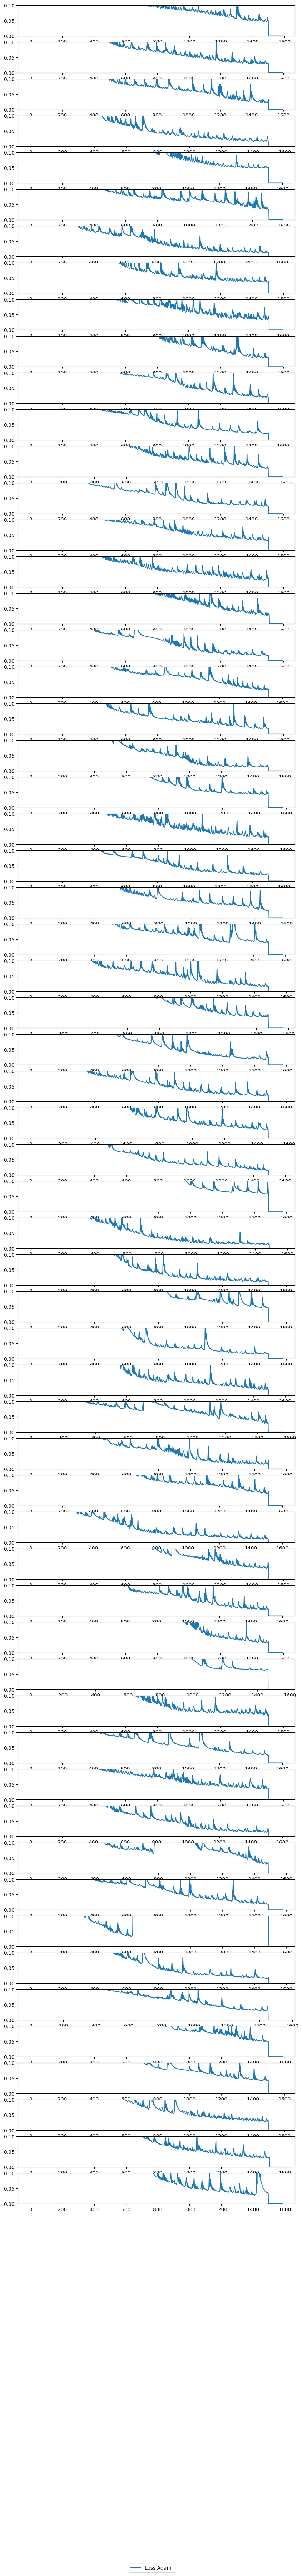

In [ ]:
fig, axes = plt.subplots(nrows=n_models, ncols=len(initial_lambdas), figsize=(10,80))

# fig, axes = plt.subplots(nrows=n_models, ncols=len(initial_lambdas), figsize=(15,5))

for i in range(n_models):
  axes[i].plot(np.linspace(0, len(hists_Adam1[i][0].transpose()),len(hists_Adam1[i][0].transpose())), hists_Adam1[i][0].transpose())
  axes[i].set_ylim([0,1e-1])
  # axes[0].plot(np.linspace(0, len(hists_Adam1[i][0].transpose()),len(hists_Adam1[i][0].transpose())), hists_Adam1[i][0].transpose())
  # axes[0].set_ylim([0,5])

  # axes[1].plot(np.linspace(0, len(hists_Adam1[i][1].transpose()), len(hists_Adam1[i][1].transpose())), hists_Adam1[i][1].transpose())
  # axes[1].set_ylim([0,5])

  # axes[2].plot(np.linspace(0, len(hists_Adam1[i][2].transpose()), len(hists_Adam1[i][2].transpose())), hists_Adam1[i][2].transpose())
  # axes[2].set_ylim([0,5])


  print(f"len Atempt-{i} and init lambda {initial_lambdas[0]}: ",len(hists_Adam1[i][0].transpose()))
  # print(f"len Atempt-{i} and init lambda {initial_lambdas[1]}: ",len(hists_Adam1[i][1].transpose()))
  # print(f"len Atempt-{i} and init lambda {initial_lambdas[2]}: ",len(hists_Adam1[i][2].transpose()))
  # print(f"len Atempt-{i} and init lambda {initial_lambdas[3]}: ",len(hists_Adam1[i][3].transpose()))

# timeout = 250
cols = ['$\hat{\lambda}_{1_0}^{(1)} = -1$', '$\hat{\lambda}_{1_0}^{(1)} = -2$', '$\hat{\lambda}_{1_0}^{(1)} = -5$']
rows = ['Attempt {}'.format(row) for row in range(1, n_models+1)]

# pad = 5 # in points


# for ax, col in zip(axes[0], cols):
#   ax.annotate(col, xy=(0.5, 1.05), xytext=(0, pad),
#               xycoords='axes fraction', textcoords='offset points',
#               size='large', ha='center', va='baseline')

# for ax, row in zip(axes[:,0], rows):
#   ax.annotate(row, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - pad, 0),
#               xycoords=ax.yaxis.label, textcoords='offset points',
#               size='large', ha='right', va='center')

# fig.tight_layout()

fig.legend(['Loss Adam '], loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=True)

plt.show()

### Predict and Evaluate Inverse Problem

In [ ]:
def lambdas(hists, iter_model, iter_init):
  return lambd_Adam1[i][0].transpose().iloc[-1,:].values[0]

df = pd.DataFrame(columns=['Adam'])
df = df.round(10)

for i in range(n_models):
  x = []
  for j in range(len(initial_lambdas)):
    x.append(lambdas(hists_Adam1, i, j))

  df.loc['Attempt '+str(i+1)] = x

print("Lambda Prediction Given U(x,t)")
df

Lambda Prediction Given U(x,t)


,Adam
Attempt 1,0.454063
Attempt 2,0.468148
Attempt 3,0.493461
Attempt 4,0.489575
Attempt 5,0.486133
Attempt 6,0.485923
Attempt 7,0.489403
Attempt 8,0.492799
Attempt 9,0.491662
Attempt 10,0.497141


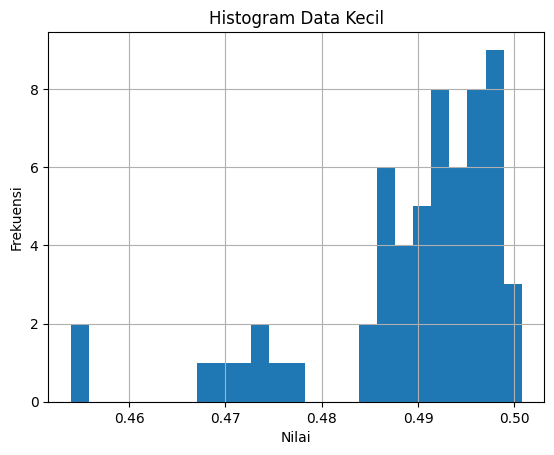

In [ ]:
# bins = np.linspace(0, 0.00009, 11)  # 20 bins antara 0 dan 0.0001
ax = df.iloc[:, 0].plot(kind='hist', bins=25, align='mid')

# plt.xticks(np.linspace(0, 0.00009, 11))  # Misal xtick tiap 0.00001
plt.xlabel("Nilai")
plt.ylabel("Frekuensi")
plt.title("Histogram Data Kecil")
plt.grid(True)
plt.show()

/usr/local/lib/python3.12/dist-packages/scipy/stats/_continuous_distns.py:796: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)


burr         KS=0.1007, p=0.5431, params=(np.float64(73.57673787802514), np.float64(0.10441103709418234), np.float64(0.414245880184817), np.float64(0.08441267875811326))
fisk         KS=0.1356, p=0.2006, params=(np.float64(577687716.373332), np.float64(-2848339.132489023), np.float64(2848339.623548127))
norm         KS=0.1830, p=0.03135, params=(np.float64(0.48933602025111517), np.float64(0.010050196915130163))
lognorm      KS=0.1830, p=0.03134, params=(np.float64(9.814393511460945e-06), -1023.5460575520977, np.float64(1024.03539352303))
invgauss     KS=0.2311, p=0.002673, params=(np.float64(0.008514898666114684), np.float64(0.363794050769516), np.float64(14.691460991632212))
beta         KS=0.2431, p=0.001318, params=(np.float64(2.4185458841361163), np.float64(0.5477405465557679), np.float64(0.4347128407148323), np.float64(0.0660436018320122))
expon        KS=0.4274, p=1.828e-10, params=(0.4539424479007721, 0.03539357235034307)
uniform      KS=0.5011, p=1.833e-14, params=(0.4539424479

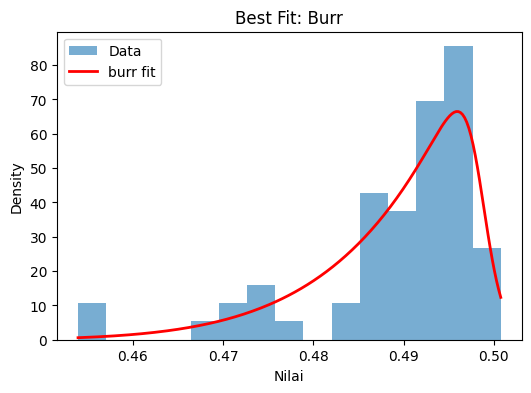

Mean: 0.4891196921064066


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# If df is a DataFrame, pick the column you want to fit:
data = df.iloc[:, 0].to_numpy()  # 1D array

distributions = [
    stats.norm,          # Normal
    stats.expon,         # Exponential
    stats.gamma,         # Gamma
    stats.beta,          # Beta
    stats.lognorm,       # Lognormal
    stats.uniform,       # Uniform
    stats.invgauss,      # Inverse Gaussian
    stats.burr,          # Burr
    stats.fisk,          # Fisk (log-logistic)
    stats.gengamma       # Generalized Gamma
]

results = {}

# Fit tiap distribusi dan uji KS
for dist in distributions:
    try:
        params = dist.fit(data)
        ks_stat, ks_pval = stats.kstest(data, dist.cdf, args=params)
        results[dist.name] = {
            "KS_stat": float(ks_stat),
            "p_value": float(ks_pval),
            "params": params
        }
    except Exception as e:
        results[dist.name] = {"KS_stat": np.inf, "p_value": 0, "params": None}
        print(f"Gagal fit {dist.name}: {e}")

# Urutkan dari KS terkecil
sorted_results = sorted(results.items(), key=lambda x: x[1]["KS_stat"])

# Tampilkan hasil
for name, res in sorted_results:
    if res["params"] is not None:
        print(f"{name:12s} KS={res['KS_stat']:.4f}, p={res['p_value']:.4g}, params={res['params']}")

# Plot best fit
best_name, best_info = sorted_results[0]
best_dist = getattr(stats, best_name)
params = best_info["params"]

x = np.linspace(min(data), max(data), 200)
pdf = best_dist.pdf(x, *params)

plt.figure(figsize=(6,4))
plt.hist(data, bins=15, density=True, alpha=0.6, label="Data")
plt.plot(x, pdf, 'r-', lw=2, label=f"{best_name} fit")
plt.title(f"Best Fit: {best_name.capitalize()}")
plt.xlabel("Nilai")
plt.ylabel("Density")
plt.legend()
plt.show()

params = stats.burr.fit(data)
mean = stats.burr.mean(*params)
print("Mean:", mean)

In [ ]:
df.describe()

,Adam
count,60.000000
mean,0.489336
std,0.010135
min,0.453942
25%,0.487030
50%,0.492269
75%,0.495977
max,0.500756


In [ ]:
print(df.mean(axis=0).round(10))
df.loc['Average'] = df.mean(axis=0)
df.loc['StdDev'] = df.std(axis=0, ddof=1)
df.loc['CV'] = df.loc['StdDev'] / df.loc['Average']
df.loc[['Average', 'StdDev', 'CV']] = df.loc[['Average', 'StdDev', 'CV']].round(10)
print(df.tail(3))

Adam    0.489336
dtype: float64
             Adam
Average  0.489336
StdDev   0.010050
CV       0.020538


## PDP Model 1 Forward

In [ ]:
n_models = 2

arch = {'output_dim':1, 'num_hidden_layers':5, 'num_neurons_per_layer':100,'activation':'swish', 'trainable_B':True, 'sigmas':[1.0,2.0], 'mapping_size':64}

models = [None] * n_models

for i in range(n_models):
  tf.random.set_seed(i)
  models[i] = PINN_NeuralNet(lb=lb, ub=ub, **arch)
  models[i].build((None, 3))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


In [ ]:
lr_comb_param = {'boundaries': [7000,10000,11000,13000,15000,20000],
                 'initial_learning_rate': 1e-2,
                 'decay_steps': 1000,
                 'decay_rate': 0.9,
                 'values_steps': 2}
lr_comb = CombinedDecays(**lr_comb_param)
lr_comb.get_config()

{'initial_learning_rate': 0.01,
 'decay_steps': 1000,
 'decay_rate': 0.9,
 'staircase': False,
 'boundaries': [7000, 10000, 11000, 13000, 15000, 20000],
 'values': [0.004782969000000001,
  0.0023914845000000003,
  0.0011957422500000002,
  0.0005978711250000001,
  0.00029893556250000004,
  0.00014946778125000002,
  7.473389062500001e-05],
 'values_steps': [2, 2, 2, 2, 2, 2],
 'name': None}

Text(0.5, 1, 'Combined Learning Rate')

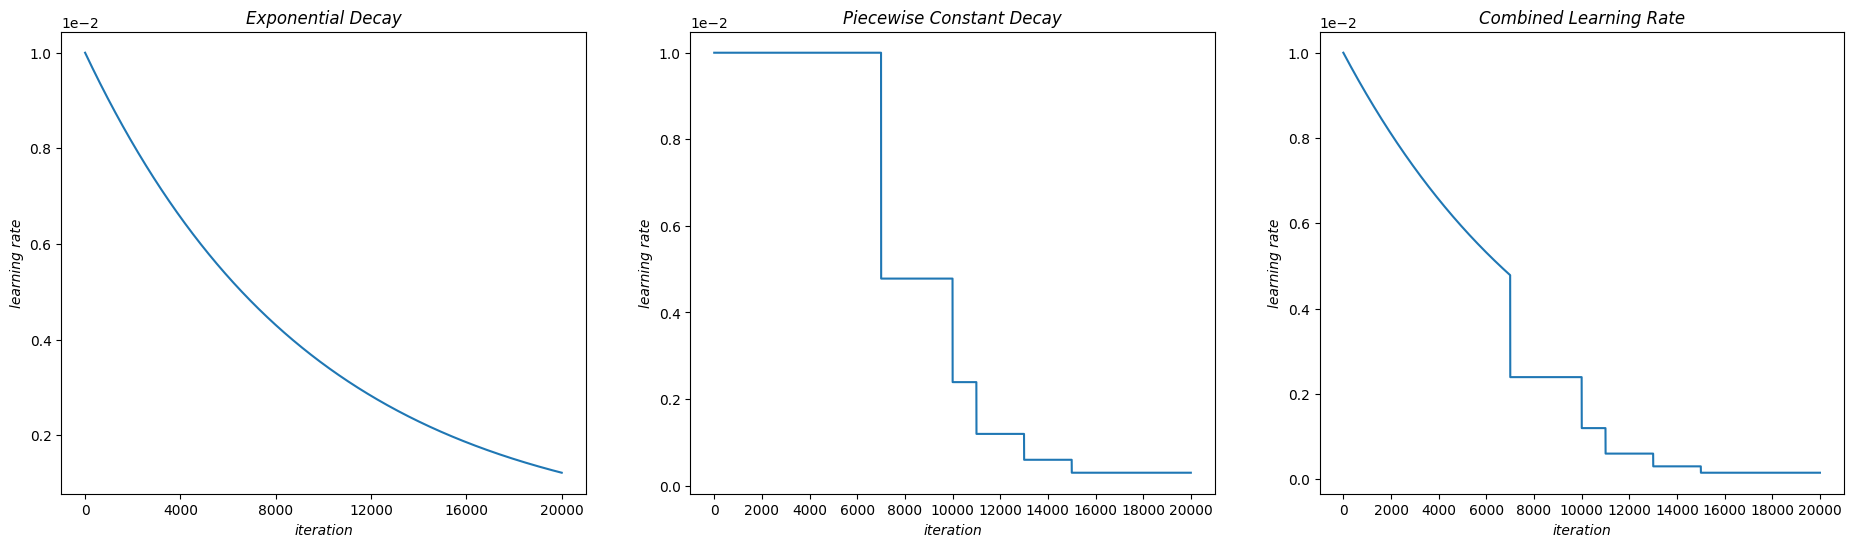

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N = 20000  # Extended range

fig = plt.figure(figsize=(23, 6))

# ExponentialDecay
initial_learning_rate = lr_comb.initial_learning_rate
decay_steps = lr_comb.decay_steps
decay_rate = lr_comb.decay_rate

learning_rate = []
for i in range(N+1):
    lr = initial_learning_rate * decay_rate ** (i / decay_steps)
    learning_rate.append(lr)

plt.subplot(1, 3, 1)
plt.plot(learning_rate)
plt.xlabel('iteration', fontstyle='italic')
plt.ylabel('learning rate', fontstyle='italic')
plt.xticks(np.arange(0, N+1, 4000))
plt.ticklabel_format(axis='y', scilimits=(0, 0))
plt.title('Exponential Decay', y=1, fontstyle='italic')

# Piecewise Constant Decay
boundaries = lr_comb.boundaries
values = lr_comb.values

learning_rate = []
for i in range(N+1):
    for j in range(len(boundaries)):
        if i <= boundaries[0]:
            lr = lr_comb.initial_learning_rate
        elif i <= boundaries[j]:
            lr = values[j-1]
            break
        else:
            lr = values[-1]
    learning_rate.append(lr)

plt.subplot(1, 3, 2)
plt.plot(learning_rate)
plt.xlabel('iteration', fontstyle='italic')
plt.ylabel('learning rate', fontstyle='italic')
plt.xticks(np.arange(0, N+1, 2000))
plt.ticklabel_format(axis='y', scilimits=(0, 0))
plt.title('Piecewise Constant Decay', y=1, fontstyle='italic')

# Extended Combined Decay
boundaries = lr_comb.boundaries
values_steps = lr_comb.values_steps  # should be a list like [2, 2, 2, ...]
if isinstance(values_steps, int):
    values_steps = [values_steps] * (len(boundaries))  # Make uniform if scalar

i_stop = boundaries[0]
learning_rate = []

learning_rate = []
i_stop = boundaries[0]

for i in range(N+1):
    if i <= i_stop:
        lr = initial_learning_rate * decay_rate ** (i / decay_steps)
    else:
        for j in range(1, len(boundaries)):
            if boundaries[j-1] < i <= boundaries[j]:
                if i == boundaries[j-1] + 1:
                    # first step into this boundary: decay from previous segment
                    prev_lr = learning_rate[-1]
                    lr = prev_lr / values_steps[j-1]
                else:
                    lr = learning_rate[-1]  # maintain constant
                break
        else:
            # After the last boundary
            lr = learning_rate[-1] / values_steps[-1]
    learning_rate.append(lr)

plt.subplot(1, 3, 3)
plt.plot(learning_rate)
plt.xlabel('iteration', fontstyle='italic')
plt.ylabel('learning rate', fontstyle='italic')
plt.xticks(np.arange(0, N+1, 2000))
plt.ticklabel_format(axis='y', scilimits=(0,0))
plt.title('Combined Learning Rate', y=1, fontstyle='italic')



In [ ]:
pred_lambda = [0.4891196921064066]

In [ ]:
timeout = 1200
start_from = 1


models_Adam_comb = [None]*n_models
hists_Adam_comb = [None]*n_models
batch_size = 4096

for i in range(start_from - 1, n_models):
    models_Adam_comb[i] = []
    hists_Adam_comb[i] = []
    for j, lambd_val in enumerate(pred_lambda):
        print('{:s}\nModel Iteration: {:d}, Lambda Iteration: {:d}\n{:s}'.format(
            50*'-', i+1, j+1, 50*'-'))

        tf.random.set_seed(i + j)  # Use a combined seed for reproducibility

        # Build and initialize model
        models_Adam_comb[i].append(PINN_NeuralNet(lb, ub, **arch))
        models_Adam_comb[i][j].build(input_shape=(None, 3))

        # Set weights and lambda from base model
        models_Adam_comb[i][j].set_weights(models[i].get_weights())
        # Prepare optimizer
        optim_Adam_comb = tf.keras.optimizers.AdamW(learning_rate=lr_comb, weight_decay =1e-3)

        # Initialize solver
        solver = PINN_PDESolver(models_Adam_comb[i][j], X_train, fun_r_fwd, get_r_fwd,lambd_val)

        # Train the model
        print('\n\nAdam - Combined Learning Rate\n')
        solver.solve_with_TFoptimizer(optim_Adam_comb, X_train, u_train, W_u, W_v,timeout=timeout,batch_size=batch_size)

        # Store training history
        hists_Adam_comb[i].append(solver.hist)

        print('\n\n\n')

--------------------------------------------------
Model Iteration: 1, Lambda Iteration: 1
--------------------------------------------------


Adam - Combined Learning Rate



/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Streaming output truncated to the last 5000 lines.
PDE Loss: 1.24468556e-06 Data Loss: 0.0128983036 Total Loss: 0.128984287
PDE Loss: 1.20079312e-06 Data Loss: 0.0107509643 Total Loss: 0.107510842
PDE Loss: 1.19020274e-06 Data Loss: 0.0109269796 Total Loss: 0.10927099
PDE Loss: 1.16728506e-06 Data Loss: 0.0101731988 Total Loss: 0.101733156
PDE Loss: 1.09081532e-06 Data Loss: 0.0109142754 Total Loss: 0.109143838
PDE Loss: 1.15991213e-06 Data Loss: 0.0102648046 Total Loss: 0.102649212
PDE Loss: 1.2260225e-06 Data Loss: 0.0111167077 Total Loss: 0.111168303
PDE Loss: 1.24452617e-06 Data Loss: 0.0100343525 Total Loss: 0.10034477
PDE Loss: 1.13284932e-06 Data Loss: 0.00975841656 Total Loss: 0.0975853
PDE Loss: 1.08524125e-06 Data Loss: 0.0101829777 Total Loss: 0.101830862
--- End of Epoch 68, Iteration 68, Average Epoch Loss: 1.157743e-01 ---
PDE Loss: 1.23364964e-06 Data Loss: 0.0133789908 Total Loss: 0.133791149
PDE Loss: 1.17485308e-06 Data Loss: 0.0170434732 Total Loss: 0.170435905
PDE L

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_3', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Streaming output truncated to the last 5000 lines.
PDE Loss: 1.15090984e-06 Data Loss: 0.0103434771 Total Loss: 0.103435919
PDE Loss: 1.23152302e-06 Data Loss: 0.0104653947 Total Loss: 0.104655176
PDE Loss: 1.1477855e-06 Data Loss: 0.0110831354 Total Loss: 0.110832497
PDE Loss: 1.22297e-06 Data Loss: 0.0112543367 Total Loss: 0.112544589
PDE Loss: 1.1754662e-06 Data Loss: 0.0118816765 Total Loss: 0.11881794
PDE Loss: 1.19255958e-06 Data Loss: 0.0102772135 Total Loss: 0.102773324
PDE Loss: 1.10716678e-06 Data Loss: 0.0115422141 Total Loss: 0.115423255
PDE Loss: 1.20851757e-06 Data Loss: 0.0100048622 Total Loss: 0.100049831
PDE Loss: 1.21321102e-06 Data Loss: 0.0114013953 Total Loss: 0.114015169
PDE Loss: 1.1278687e-06 Data Loss: 0.0103705358 Total Loss: 0.103706487
PDE Loss: 1.18420689e-06 Data Loss: 0.00979164429 Total Loss: 0.0979176238
PDE Loss: 1.2679061e-06 Data Loss: 0.0114368172 Total Loss: 0.114369437
PDE Loss: 1.18758953e-06 Data Loss: 0.0115024447 Total Loss: 0.115025632
PDE Lo

In [ ]:
path = dir + "COModel/Fourier/Bangkok_Fourier_swish_fwd/"

In [ ]:
for i in range(n_models):
  for j in range(len(pred_lambda)):
    models_Adam_comb[i][j].save_weights(path+"_"+str(i)+"_model_Adam_comb_"+str(j)+".weights.h5", 'h5')


for i in range(n_models):
  for j in range(len(pred_lambda)):
    np.savetxt(path + "loss/_hist_Adam_comb_" + str(i) + "_" + str(j) + ".csv", hists_Adam_comb[i][j], delimiter=",")

In [ ]:
n_models = 5

models_Adam_comb = [None] * n_models

for i in range(0, n_models):
    models_Adam_comb[i] = []
    for j in range(len(pred_lambda)):
        models_Adam_comb[i].append(PINN_NeuralNet(lb, ub, **arch))
        models_Adam_comb[i][j].build(input_shape=(None, 3))
        _ = models_Adam_comb[i][j](tf.zeros((1, 3)))
        models_Adam_comb[i][j].load_weights(
            path + "_" + str(i) + "_model_Adam_comb_" + str(j) + ".weights.h5"
        )

hists_Adam_comb = [None] * n_models

for i in range(0,n_models):
    hists_Adam_comb[i] = []
    for j in range(len(pred_lambda)):
        hists_Adam_comb[i].append(pd.read_csv(path + "/loss/_hist_Adam_comb_" + str(i) + "_" + str(j) + ".csv",header=None))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_4', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_5', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_6', howeve

### Loss Function

len Atempt-0 Lambda ke- 0:  147
\\
len Atempt-1 Lambda ke- 0:  147
\\
len Atempt-2 Lambda ke- 0:  150
\\
len Atempt-3 Lambda ke- 0:  149
\\
len Atempt-4 Lambda ke- 0:  148
\\


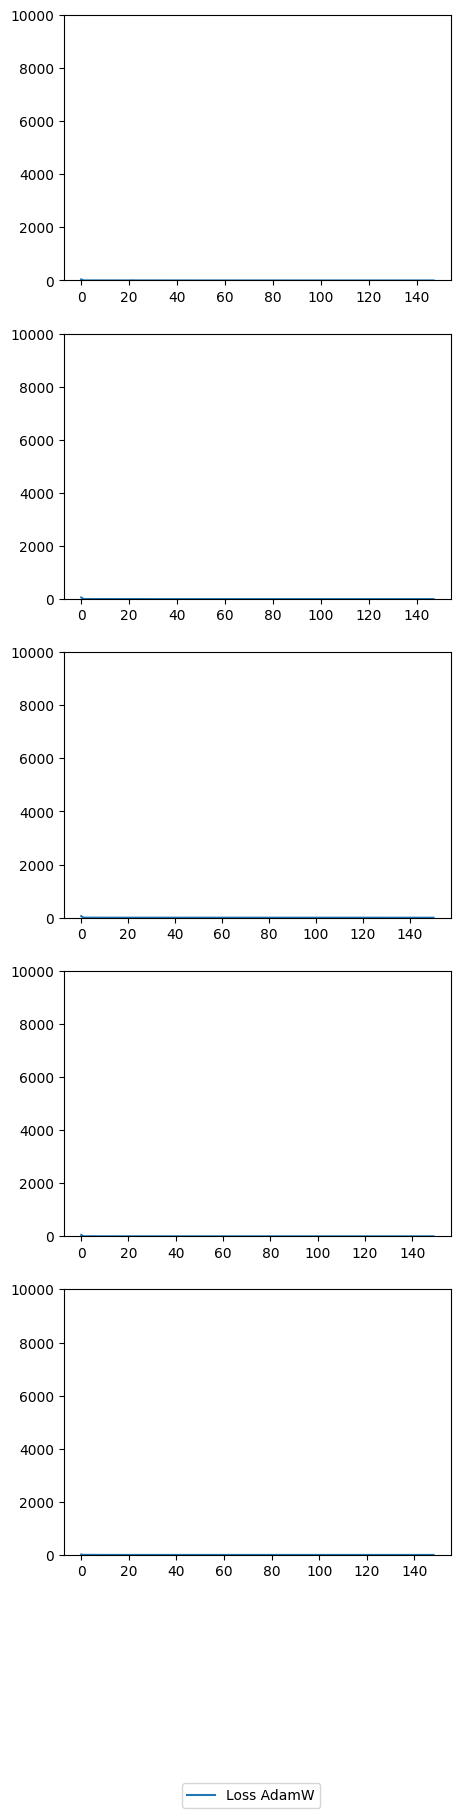

In [ ]:
fig, axes = plt.subplots(nrows=n_models, ncols=len(pred_lambda), figsize=(5,20))

for i in range(n_models):
  for j in range(len(pred_lambda)):
    axes[i].plot(np.linspace(0, len(hists_Adam_comb[i][j]),len(hists_Adam_comb[i][j])), hists_Adam_comb[i][j])
    axes[i].set_ylim([0,1e4])
  # for j in range(len(pred_lambda)):
  #   axes[j].plot(np.linspace(0, len(hists_Adam_comb[i][j]),len(hists_Adam_comb[i][j])), hists_Adam_comb[i][j])
  #   axes[j].set_ylim([0,5e4])


    print(f"len Atempt-{i} Lambda ke- {j}: ",len(hists_Adam_comb[i][j]))
  print("\\\\")

  rows = ['Attempt {}'.format(row) for row in range(1, n_models+1)]

fig.legend(['Loss AdamW'], loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=True)

plt.show()

### Prediction and Evaluation

In [ ]:
t_unique = np.sort(test_df['time'].unique())
x_unique = np.sort(test_df['x_coord'].unique())
y_unique = np.sort(test_df['y_coord'].unique())


In [ ]:
lb = tf.constant(lb, dtype=tf.float32)
ub = tf.constant(ub, dtype=tf.float32)

In [ ]:
train_Adam_comb = []


t_unique_train = np.sort(train_df['time'].unique())
x_unique_train = np.sort(train_df['x_coord'].unique())
y_unique_train = np.sort(train_df['y_coord'].unique())


for i in range(n_models):
  for j in range(len(pred_lambda)):
    train_Adam_comb.append(predict_solution(models_Adam_comb[i][j], X_train, t_unique_train, x_unique_train, y_unique_train))


df = pd.DataFrame(columns=['Adam'])
initial_lambdas = pred_lambda

# Evaluate and populate the DataFrame
for i in range(n_models):
    results = []
    for j in range(len(initial_lambdas)):
        # Evaluate solutions
        # eval_sgd = pinn.evaluate_solution(preds_SGD[i * len(initial_lambdas) + j], u_star)
        pred_t0 = train_Adam_comb[i * len(initial_lambdas) + j]
        eval_adam = evaluate_solution(pred_t0.numpy(), u_train.numpy())

        # Append results for each lambda
        # results.append(eval_sgd)
        results.append(eval_adam)

    # Add results to DataFrame
    df.loc[f'Attempt {i+1}'] = results

# Display the DataFrame
df


,Adam
Attempt 1,"(0.060739644, 1.5607454)"
Attempt 2,"(0.056045864, 1.4499824)"
Attempt 3,"(0.057888433, 1.5127321)"
Attempt 4,"(0.05751352, 1.5026236)"
Attempt 5,"(0.049616717, 1.2743032)"


In [ ]:
t_unique = np.sort(test_df['time'].unique())
x_unique = np.sort(test_df['x_coord'].unique())
y_unique = np.sort(test_df['y_coord'].unique())

preds_Adam_comb = []

for i in range(n_models):
  for j in range(len(pred_lambda)):
    preds_Adam_comb.append(predict_solution(models_Adam_comb[i][j], X_test, t_unique, x_unique, y_unique))


In [ ]:
df = pd.DataFrame(columns=['Adam'])
initial_lambdas = pred_lambda

# Evaluate and populate the DataFrame
for i in range(n_models):
    results = []
    for j in range(len(initial_lambdas)):
        # Evaluate solutions
        # eval_sgd = pinn.evaluate_solution(preds_SGD[i * len(initial_lambdas) + j], u_star)
        pred_t0 = preds_Adam_comb[i * len(initial_lambdas) + j]
        eval_adam = evaluate_solution(pred_t0.numpy(), u_test.numpy())

        # Append results for each lambda
        # results.append(eval_sgd)
        results.append(eval_adam)

    # Add results to DataFrame
    df.loc[f'Attempt {i+1}'] = results

# Display the DataFrame
df


,Adam
Attempt 1,"(0.061256636, 1.575124)"
Attempt 2,"(0.05695366, 1.4747409)"
Attempt 3,"(0.058626708, 1.5320672)"
Attempt 4,"(0.058226112, 1.5215216)"
Attempt 5,"(0.050589688, 1.3011305)"


In [ ]:
def summarise_attempts(df: pd.DataFrame) -> pd.DataFrame:
    """
    Return a tidy table with mean, sample‑SD and CV
    for both numbers contained in each tuple cell.
    """
    summaries = {}
    for col in df.columns:
        arr = np.vstack(df[col].to_numpy())     # shape = (n_attempts, 2)
        μ  = arr.mean(axis=0)                   # mean
        σ  = arr.std(axis=0, ddof=1)            # sample SD (ddof=1)
        cv = σ / μ                              # coefficient of variation
        summaries[col] = {
            "mean_MAE": μ[0], "sd_MAE": σ[0], "cv_MAE": cv[0],
            "mean_MAPE": μ[1], "sd_MAPE": σ[1], "cv_MAPE": cv[1],
        }
    return pd.DataFrame(summaries).T

stats_df = summarise_attempts(df)
print(stats_df)

      mean_MAE    sd_MAE    cv_MAE  mean_MAPE   sd_MAPE  cv_MAPE
Adam  0.057131  0.003977  0.069619   1.480917  0.106655  0.07202


In [ ]:
weights = models_Adam_comb[4][0].get_weights()

for i, w in enumerate(weights):
    print(f"Weight {i}: shape = {w.shape}")
    print(w)

Weight 0: shape = (3, 64)
[[-1.6826028   1.2913477  -0.7835729  -1.389749    0.12507105 -0.42086545
  -0.52496463 -2.589274    1.9225552   0.8285143  -2.266162    0.5155931
  -1.2048501  -0.6759189  -0.9377711   0.93471736 -0.22762616 -0.11266273
  -0.27593574  0.6432613   2.0656865  -0.0363964  -0.8217581   0.13363796
  -0.78287774 -0.84204155 -0.5448444  -0.6997988  -1.0040214  -0.8424453
   0.9599082   0.6561611  -0.25700635  0.9969771   0.92761695 -3.284646
   1.3125718   0.6047895  -1.7305301   0.7522407  -1.0439739   0.67265725
  -1.1813092   0.08066829  3.0627315   1.0356891   0.16187039  0.52267325
   1.2185652   0.32472345  0.12498809  1.1965567  -0.01992359 -0.8216529
  -0.25482625 -1.4920833   1.641566    0.39784902 -0.2580191   1.835945
  -2.024815    0.24220318 -0.8276837  -0.5885822 ]
 [-1.1896739   0.32004374  0.04107803 -0.2658944   0.18870622  0.2749384
   0.86058813  0.20756724 -0.11720905 -0.79986334 -0.43631902  2.4848523
   2.7395701   1.2505146   0.61245674 -2.544